In [1]:
#!/bin/bash
!curl -L -o loan-risk-prediction.zip\
  https://www.kaggle.com/api/v1/datasets/download/sohailkhan05/loan-risk-prediction

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 74743  100 74743    0     0   146k      0 --:--:-- --:--:-- --:--:--  447k


In [2]:
!unzip /content/loan-risk-prediction.zip

Archive:  /content/loan-risk-prediction.zip
  inflating: loan_risk_prediction_dataset.csv  


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/loan_risk_prediction_dataset.csv')

In [5]:
df

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0
...,...,...,...,...,...,...,...,...,...,...
4995,24,36780.0,23383.0,NaN,23,Male,Masters,Houston,Salaried,0
4996,66,99146.0,9760.0,306.0,14,Male,PhD,New York,Unemployed,0
4997,26,58100.0,18230.0,311.0,10,Female,High School,San Francisco,Self-Employed,0
4998,53,58513.0,12373.0,813.0,23,Male,PhD,Houston,Salaried,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB


In [7]:
df.isna().sum()

,0
Age,0
Income,196
LoanAmount,0
CreditScore,194
YearsExperience,0
Gender,0
Education,198
City,0
EmploymentType,0
LoanApproved,0


In [8]:
df.duplicated().sum()

np.int64(0)

/tmp/ipykernel_1834/3188250606.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='LoanApproved', palette='Set2')


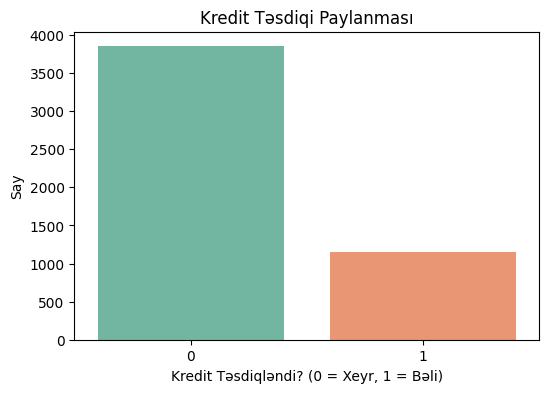

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='LoanApproved', palette='Set2')
plt.title('Kredit Təsdiqi Paylanması')
plt.xlabel('Kredit Təsdiqləndi? (0 = Xeyr, 1 = Bəli)')
plt.ylabel('Say')

plt.show()

In [10]:
print(df['LoanApproved'].value_counts())
print(df['LoanApproved'].value_counts(normalize=True) * 100)

LoanApproved
0    3849
1    1151
Name: count, dtype: int64
LoanApproved
0    76.98
1    23.02
Name: proportion, dtype: float64


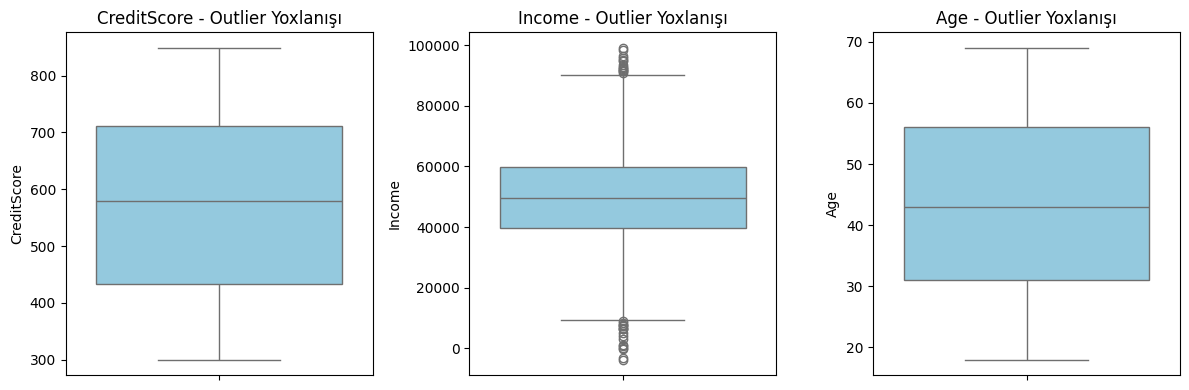

In [11]:
numerical_cols = ['CreditScore', 'Income', 'Age']

plt.figure(figsize=(12, 4))
for i, col in enumerate(numerical_cols, 1):
  plt.subplot(1, 3, i)
  sns.boxplot(data=df, y=col, color='skyblue')
  plt.title(f'{col} - Outlier Yoxlanışı')

plt.tight_layout()
plt.show()

In [12]:
df['Income'].fillna(df['Income'].median(), inplace=True)

/tmp/ipykernel_1834/1959487941.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].median(), inplace=True)


In [13]:
df['CreditScore'].fillna(df['CreditScore'].median(), inplace=True)

/tmp/ipykernel_1834/4249448881.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CreditScore'].fillna(df['CreditScore'].median(), inplace=True)


In [14]:
df['Education'].fillna(df['Education'].mode()[0], inplace=True)

/tmp/ipykernel_1834/593309154.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Education'].fillna(df['Education'].mode()[0], inplace=True)


In [15]:
df.isnull().sum()

,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
YearsExperience,0
Gender,0
Education,0
City,0
EmploymentType,0
LoanApproved,0


In [16]:
from sklearn.model_selection import train_test_split

In [17]:
df = pd.get_dummies(df, columns=['Gender', 'Education', 'City', 'EmploymentType'], drop_first=True)

In [24]:
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved,Gender_Male,Education_High School,Education_Masters,Education_PhD,City_Houston,City_New York,City_San Francisco,EmploymentType_Self-Employed,EmploymentType_Unemployed
0,56,48353.0,31258.0,675.0,20,0,False,True,False,False,True,False,False,False,True
1,69,57462.0,23262.0,586.0,6,0,True,True,False,False,False,False,True,True,False
2,46,44219.0,26530.0,781.0,26,1,True,False,False,True,True,False,False,True,False
3,32,56307.0,11531.0,549.0,11,0,True,False,False,False,False,True,False,False,True
4,60,37034.0,27871.0,500.0,19,0,False,True,False,False,False,False,False,False,True


In [19]:
X = df.drop(columns=['LoanApproved'], axis=1)
y = df['LoanApproved']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [22]:
from sklearn.tree import DecisionTreeClassifier

In [25]:
model = DecisionTreeClassifier(random_state=42)

In [27]:
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [28]:
y_pred = model.predict(X_test)

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [30]:
y_train_pred = model.predict(X_train)

In [31]:
accuracy_score(y_test, y_pred)

0.929

In [32]:
accuracy_score(y_train, y_train_pred)

1.0

In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       770
           1       0.84      0.85      0.85       230

    accuracy                           0.93      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.93      0.93      0.93      1000



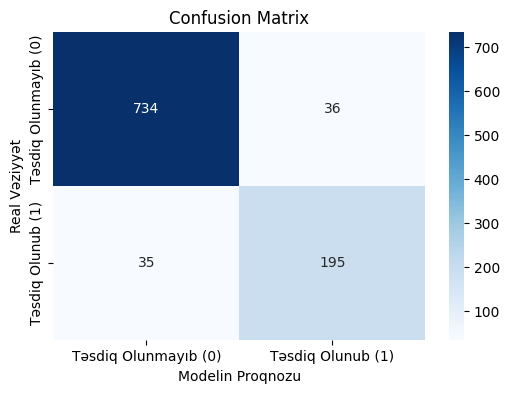

In [34]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Təsdiq Olunmayıb (0)', 'Təsdiq Olunub (1)'],
            yticklabels=['Təsdiq Olunmayıb (0)', 'Təsdiq Olunub (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Modelin Proqnozu')
plt.ylabel('Real Vəziyyət')

plt.show()

In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree

In [36]:
param_grid = {
    'max_depth': [3, 4, 5, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_dt_model = grid_search.best_estimator_

print("--- Ən Yaxşı Parametrlər ---")
print(best_params)

new_train_acc = accuracy_score(y_train, best_dt_model.predict(X_train))
new_test_acc = accuracy_score(y_test, best_dt_model.predict(X_test))

print(new_train_acc)
print(new_test_acc)

--- Ən Yaxşı Parametrlər ---
{'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 8, 'min_samples_split': 2}
0.971
0.964


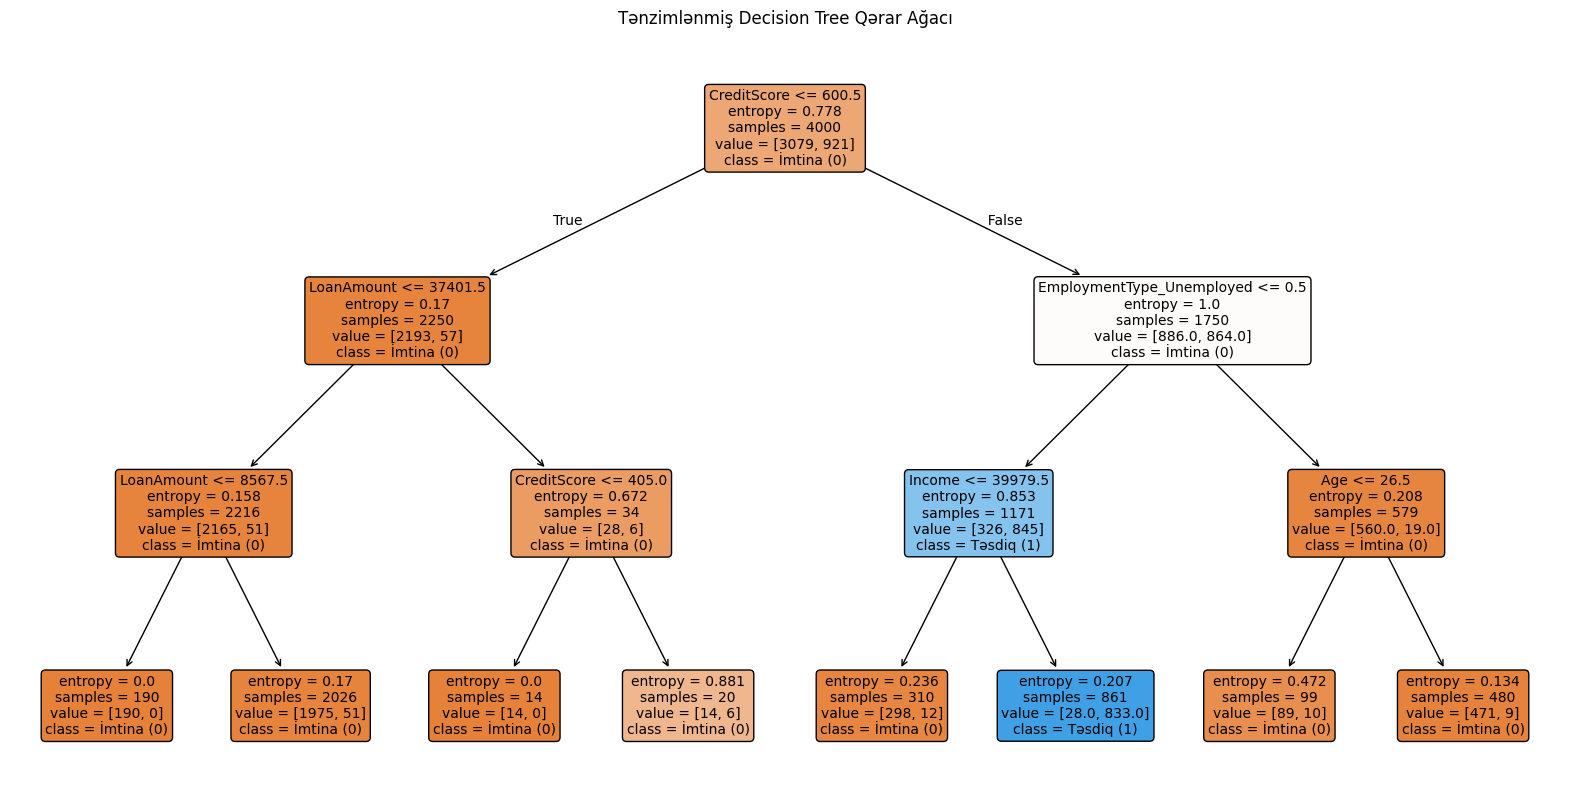

In [37]:
plt.figure(figsize=(20,10))
plot_tree(best_dt_model,
          feature_names=X.columns,
          class_names=['İmtina (0)', 'Təsdiq (1)'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Tənzimlənmiş Decision Tree Qərar Ağacı")

plt.show()